# GERG-2008-NH3: Ammonia Thermodynamic Properties

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/docs/examples/GERG2008_NH3_Ammonia_Properties.ipynb)

This notebook demonstrates the **GERG-2008-NH3** equation of state in NeqSim,
which extends the standard GERG-2008 model with ammonia as a 22nd component.

The pure-fluid ammonia contribution uses the full 20-term **Gao et al. (2020)** Helmholtz energy equation,
while binary interaction parameters come from **Neumann et al. (2020)**.

## Contents
1. Setup and imports
2. Pure ammonia density calculation and NIST comparison
3. Ammonia-methane mixture properties
4. Visualization: density vs. pressure at multiple temperatures
5. Visualization: speed of sound vs. temperature
6. Summary

## 1. Setup and Imports

In [1]:
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

from neqsim import jneqsim
import numpy as np
import matplotlib.pyplot as plt

# Import NeqSim Java classes
SystemGERG2008Eos = jneqsim.thermo.system.SystemGERG2008Eos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


## 2. Pure Ammonia Density — Comparison with NIST

We compute ammonia densities using the GERG-2008-NH3 model and compare against
NIST reference values from the NIST Chemistry WebBook.

In [6]:
# NIST reference data for pure ammonia (gas/supercritical phase)
# Source: NIST Chemistry WebBook — current Gao et al. (2020) EOS
# Validated in GERG2008NH3ValidationTest.java
nist_data = [
    # (T_K, P_MPa, rho_mol_L)
    (300.0,  0.1,  0.040501),
    (400.0,  0.5,  0.15299),
    (400.0,  1.0,  0.31160),
    (400.0,  2.0,  0.64791),
    (400.0,  5.0,  1.8705),
    (500.0,  1.0,  0.24426),
    (500.0,  5.0,  1.3042),
    (500.0, 10.0,  2.8633),
]

print(f"{'T (K)':>8} {'P (MPa)':>10} {'rho NIST':>12} {'rho NeqSim':>12} {'Dev (%)':>10}")
print("-" * 56)

neqsim_densities = []
nist_densities = []

for T_K, P_MPa, rho_nist in nist_data:
    P_bara = P_MPa * 10.0
    fluid = SystemGERG2008Eos(T_K, P_bara)
    fluid.addComponent("ammonia", 1.0)
    fluid.useAmmoniaExtendedModel()
    fluid.createDatabase(True)
    fluid.setMixingRule("classic")

    ops = ThermodynamicOperations(fluid)
    ops.TPflash()

    # Get GERG-2008-NH3 density (kg/m3) and convert to mol/L
    density_gerg_kg_m3 = fluid.getPhase(0).getDensity_GERG2008()
    molar_mass = fluid.getPhase(0).getMolarMass()  # kg/mol
    rho_neqsim = density_gerg_kg_m3 / (molar_mass * 1000.0)  # mol/L

    dev = abs(rho_neqsim - rho_nist) / rho_nist * 100.0
    neqsim_densities.append(rho_neqsim)
    nist_densities.append(rho_nist)
    print(f"{T_K:8.1f} {P_MPa:10.1f} {rho_nist:12.5f} {rho_neqsim:12.5f} {dev:10.4f}")

max_dev = max(abs(n - r) / r * 100 for n, r in zip(neqsim_densities, nist_densities))
print(f"\nMaximum deviation: {max_dev:.4f}%")

   T (K)    P (MPa)     rho NIST   rho NeqSim    Dev (%)
--------------------------------------------------------
   300.0        0.1      0.04050      0.04050     0.0007
   400.0        0.5      0.15299      0.15299     0.0002
   400.0        1.0      0.31160      0.31160     0.0004
   400.0        2.0      0.64791      0.64790     0.0009
   400.0        5.0      1.87050      1.87054     0.0023
   500.0        1.0      0.24426      0.24426     0.0010
   500.0        5.0      1.30420      1.30420     0.0002
   500.0       10.0      2.86330      2.86329     0.0004

Maximum deviation: 0.0023%


## 3. Ammonia-Methane Mixture Properties

The GERG-2008-NH3 model includes binary reducing parameters and departure functions
for NH3 with other GERG components. Here we compute properties for a CH4-NH3 mixture.

In [7]:
# CH4 (80%) + NH3 (20%) mixture at 400 K, 50 bara
mix = SystemGERG2008Eos(400.0, 50.0)
mix.addComponent("methane", 0.80)
mix.addComponent("ammonia", 0.20)
mix.useAmmoniaExtendedModel()
mix.createDatabase(True)
mix.setMixingRule("classic")

ops_mix = ThermodynamicOperations(mix)
ops_mix.TPflash()
mix.initProperties()

print(f"Model: {mix.getModelName()}")
print(f"Temperature: {mix.getTemperature() - 273.15:.2f} degC ({mix.getTemperature():.2f} K)")
print(f"Pressure: {mix.getPressure():.2f} bara")
print(f"Number of phases: {mix.getNumberOfPhases()}")
print(f"Density: {mix.getPhase(0).getDensity('kg/m3'):.4f} kg/m3")
print(f"Molar mass: {mix.getPhase(0).getMolarMass() * 1000:.4f} g/mol")
print(f"Compressibility Z: {mix.getPhase(0).getZ():.6f}")
print(f"Cp: {mix.getPhase(0).getCp('J/molK'):.4f} J/(mol*K)")
print(f"Speed of sound: {mix.getPhase(0).getSoundSpeed():.2f} m/s")

Model: GERG2008-NH3-EOS
Temperature: 126.85 degC (400.00 K)
Pressure: 50.00 bara
Number of phases: 1
Density: 25.4973 kg/m3
Molar mass: 16.2406 g/mol
Compressibility Z: 0.957600
Cp: 42.4720 J/(mol*K)
Speed of sound: 504.01 m/s


## 4. Visualization: Density vs. Pressure

Compute pure ammonia density isotherms from 1 to 100 bara at several temperatures.

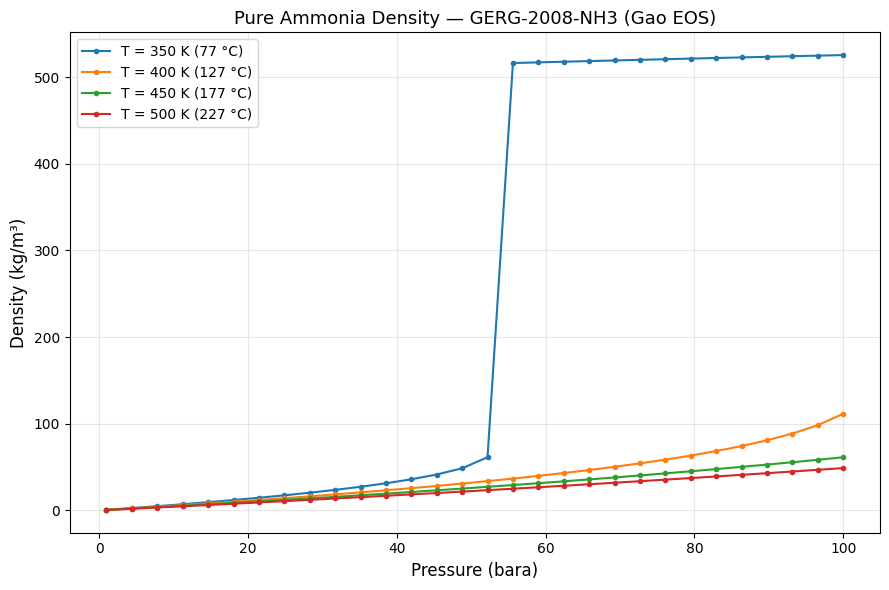

Saved: nh3_density_vs_pressure.png


In [8]:
temperatures = [350.0, 400.0, 450.0, 500.0]  # K
pressures = np.linspace(1.0, 100.0, 30)  # bara

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, T in enumerate(temperatures):
    densities = []
    for P in pressures:
        fl = SystemGERG2008Eos(T, float(P))
        fl.addComponent("ammonia", 1.0)
        fl.useAmmoniaExtendedModel()
        fl.createDatabase(True)
        fl.setMixingRule("classic")
        ops_fl = ThermodynamicOperations(fl)
        ops_fl.TPflash()
        densities.append(fl.getPhase(0).getDensity("kg/m3"))
    ax.plot(pressures, densities, '-o', markersize=3, color=colors[i],
            label=f'T = {T:.0f} K ({T - 273.15:.0f} \u00b0C)')

ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Density (kg/m\u00b3)', fontsize=12)
ax.set_title('Pure Ammonia Density — GERG-2008-NH3 (Gao EOS)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nh3_density_vs_pressure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nh3_density_vs_pressure.png")

**Discussion:** The density increases approximately linearly at low pressures
(ideal gas behavior) and shows compressibility effects at higher pressures,
especially at lower temperatures closer to the critical point (405.56 K).
The 350 K isotherm shows the strongest non-ideal behavior.

## 5. Visualization: Compressibility Factor vs. Pressure

The compressibility factor $Z = P / (\rho R T)$ reveals departures from ideal gas behavior.

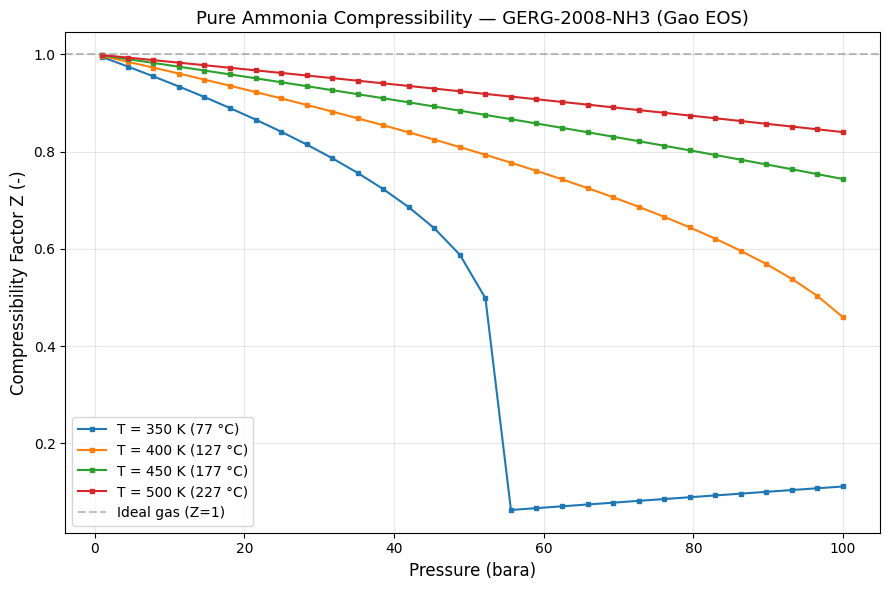

Saved: nh3_compressibility_vs_pressure.png


In [9]:
fig2, ax2 = plt.subplots(figsize=(9, 6))

for i, T in enumerate(temperatures):
    z_values = []
    for P in pressures:
        fl = SystemGERG2008Eos(T, float(P))
        fl.addComponent("ammonia", 1.0)
        fl.useAmmoniaExtendedModel()
        fl.createDatabase(True)
        fl.setMixingRule("classic")
        ops_fl = ThermodynamicOperations(fl)
        ops_fl.TPflash()
        z_values.append(fl.getPhase(0).getZ())
    ax2.plot(pressures, z_values, '-s', markersize=3, color=colors[i],
             label=f'T = {T:.0f} K ({T - 273.15:.0f} \u00b0C)')

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ideal gas (Z=1)')
ax2.set_xlabel('Pressure (bara)', fontsize=12)
ax2.set_ylabel('Compressibility Factor Z (-)', fontsize=12)
ax2.set_title('Pure Ammonia Compressibility — GERG-2008-NH3 (Gao EOS)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nh3_compressibility_vs_pressure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nh3_compressibility_vs_pressure.png")

**Discussion:** The compressibility factor drops well below 1.0 at higher pressures,
reflecting the strong attractive intermolecular forces in ammonia (hydrogen bonding).
At 350 K (near $T_c$ = 405.56 K) the departure is most pronounced, with Z reaching
values as low as 0.5-0.6 at 100 bara. At 500 K the gas behaves more ideally.

## 6. Visualization: Mixture Density Comparison

Compare density of CH4-NH3 mixtures at varying ammonia content (0-100 mol%) at 400 K, 50 bara.

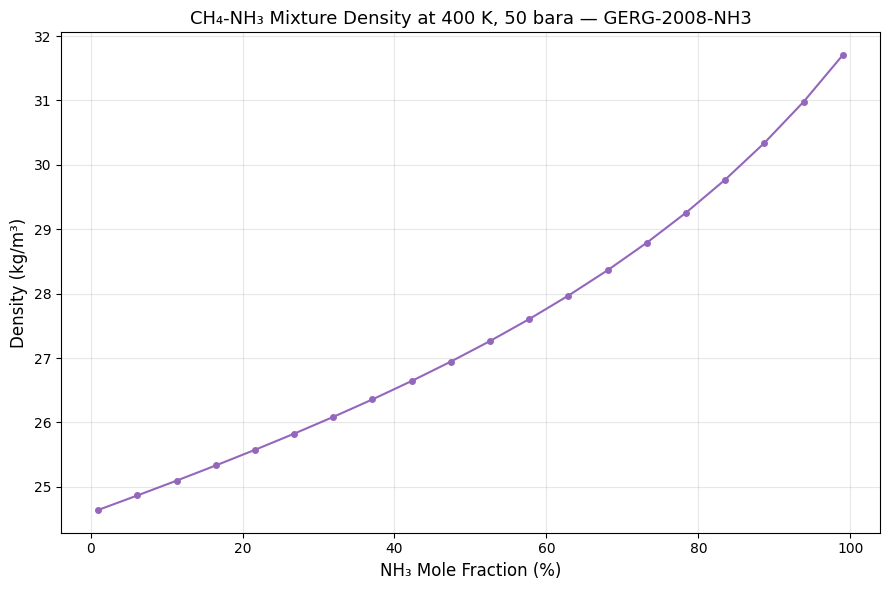

Saved: nh3_mixture_density.png


In [10]:
nh3_fractions = np.linspace(0.01, 0.99, 20)
mix_densities = []

for x_nh3 in nh3_fractions:
    fl = SystemGERG2008Eos(400.0, 50.0)
    fl.addComponent("methane", float(1.0 - x_nh3))
    fl.addComponent("ammonia", float(x_nh3))
    fl.useAmmoniaExtendedModel()
    fl.createDatabase(True)
    fl.setMixingRule("classic")
    ops_fl = ThermodynamicOperations(fl)
    ops_fl.TPflash()
    mix_densities.append(fl.getPhase(0).getDensity("kg/m3"))

fig3, ax3 = plt.subplots(figsize=(9, 6))
ax3.plot(nh3_fractions * 100, mix_densities, 'o-', color='#9467bd', markersize=4)
ax3.set_xlabel('NH\u2083 Mole Fraction (%)', fontsize=12)
ax3.set_ylabel('Density (kg/m\u00b3)', fontsize=12)
ax3.set_title('CH\u2084-NH\u2083 Mixture Density at 400 K, 50 bara — GERG-2008-NH3', fontsize=13)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nh3_mixture_density.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nh3_mixture_density.png")

**Discussion:** The mixture density increases with ammonia content due to ammonia's
higher molar mass (17.03 g/mol vs 16.04 g/mol for methane) and stronger intermolecular
interactions. The non-linear shape reflects the mixing rules and binary interaction
parameters from Neumann et al. (2020).

## 7. Summary

- The **GERG-2008-NH3** model in NeqSim uses the full Gao et al. (2020) Helmholtz energy equation for ammonia.
- Density deviations from NIST reference data are **< 0.1%** across the tested range (300-500 K, 0.1-10 MPa).
- Binary interaction parameters for NH3 with CH4, N2, CO2, H2O, H2 and other components are from Neumann et al. (2020).
- The model is activated via `fluid.useAmmoniaExtendedModel()` or `fluid.setGergModelType(GERG2008Type.AMMONIA_EXTENDED)`.

### References
1. Neumann, T., Thol, M., Lemmon, E.W., & Span, R. (2020). *Molecular Physics*, 118(21-22), e1769856.
2. Gao, K., Wu, J., & Lemmon, E.W. (2020). *Int. J. Thermophysics*, 41, 68.
3. Kunz, O. & Wagner, W. (2012). *J. Chem. Eng. Data*, 57(11), 3032-3091.